# Supervised and Unsupervised Learning: Environmental Determinants of Regional Mental Distress

Initial supervised and unsupervised learning question: **Can tracking regional pollution help predict population-level mental distress?**

We use imputed county panel data to align with the following requirements:

- **Supervised learning:** predict next-year frequent mental distress (FMD) prevalence from current-year air quality, climate proxy, and socioeconomic features.
- **Unsupervised learning:** we are interested in clustering counties on environmental and census features and evaluating whether held-out FMD shows meaningful differences across the discovered socio-environmental profiles.

We shift FMD forward within each county before modeling to prevent leakage.

Our target is predictive (not causal), and we are interested in whether environmental, climate, and socioeconomic features show meaningful correlations with future FMD prevalence.

## 0. Setup

**Note:** Run the optional install cell only if your notebook environment is missing packages. Also, the core modeling sections expect `scikit-learn`; `UMAP` and `geopandas` are optional because the notebook includes fallbacks.

In [84]:
# Optional: uncomment and run if your environment is missing these packages.
# %pip install scikit-learn matplotlib seaborn scipy umap-learn geopandas shapely

In [86]:
from pathlib import Path
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score
from sklearn.model_selection import GridSearchCV, GroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

try:
    import umap.umap_ as umap
    HAS_UMAP = True
except Exception:
    HAS_UMAP = False

try:
    from scipy.stats import f_oneway
    HAS_SCIPY = True
except Exception:
    HAS_SCIPY = False

try:
    import geopandas as gpd
    from shapely import wkt
    HAS_GEO = True
except Exception:
    HAS_GEO = False

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")

## 1. Load the Imputed County Panel

The dataset is expected at `imputation/county_panel_imputed.csv` relative to the project folder. If you move this notebook, update `DATA_PATH` below.

In [89]:
PROJECT_DIR = Path.cwd()
DATA_PATH = PROJECT_DIR / "imputation" / "county_panel_imputed.csv"

if not DATA_PATH.exists():
    # Fallback for running from a different working directory.
    DATA_PATH = Path("/Users/sophiaboettcher/Milestone-II-Project/imputation/county_panel_imputed.csv")

raw = pd.read_csv(DATA_PATH)
print(f"Loaded {DATA_PATH}")
print(f"Rows: {raw.shape[0]:,} | Columns: {raw.shape[1]:,}")
display(raw.head())

Loaded /Users/sophiaboettcher/Milestone-II-Project/imputation/county_panel_imputed.csv
Rows: 14,748 | Columns: 28


,geoid,county_name,state_name,year,median_income,poverty_count,population,unemployed_count,mental_health_prevalence,lower_ci,...,Hazardous Days,Max AQI,90th Percentile AQI,Median AQI,Days CO,Days NO2,Days Ozone,Days PM2.5,Days PM10,geometry
0,17051,Fayette,Illinois,2019,46650,3421,21565,525,17.0,15.7,...,0.0,97.817256,57.161940,43.220894,0.0,11.946166,181.641213,117.034640,0.225170,POINT (-89.02422026 39.00018837)
1,17107,Logan,Illinois,2019,57308,2323,29003,738,14.9,13.6,...,0.0,98.355691,61.043189,45.716832,0.0,8.796758,152.894562,185.949504,0.111378,POINT (-89.36756428 40.12456067)
2,17165,Saline,Illinois,2019,44090,4936,23994,816,17.3,15.8,...,0.0,89.625114,56.144275,43.475658,0.0,0.196990,201.887084,102.667771,2.465344,POINT (-88.54097347 37.75324113)
3,17097,Lake,Illinois,2019,89427,54273,701473,19357,12.0,11.0,...,0.0,115.000000,58.000000,40.000000,0.0,0.000000,245.000000,0.000000,0.000000,POINT (-88.0038997 42.32324586)
4,17127,Massac,Illinois,2019,47481,2331,14219,259,16.9,15.4,...,0.0,86.714704,56.644052,44.081068,0.0,0.685216,169.277588,124.713925,4.155977,POINT (-88.70788222 37.21907548)


In [91]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14748 entries, 0 to 14747
Data columns (total 28 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   geoid                                14748 non-null  int64  
 1   county_name                          14748 non-null  object 
 2   state_name                           14748 non-null  object 
 3   year                                 14748 non-null  int64  
 4   median_income                        14748 non-null  int64  
 5   poverty_count                        14748 non-null  int64  
 6   population                           14748 non-null  int64  
 7   unemployed_count                     14748 non-null  int64  
 8   mental_health_prevalence             14748 non-null  float64
 9   lower_ci                             14748 non-null  float64
 10  upper_ci                             14748 non-null  float64
 11  total_population            

In [93]:
summary = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing": raw.isna().sum(),
    "missing_pct": (raw.isna().mean() * 100).round(2),
    "n_unique": raw.nunique(dropna=True),
})
display(summary)

print("Years:", sorted(raw["year"].unique()))
print("Unique counties:", raw["geoid"].nunique())
print("Duplicate county-year rows:", raw.duplicated(["geoid", "year"]).sum())

,dtype,missing,missing_pct,n_unique
geoid,int64,0,0.0,3008
county_name,object,0,0.0,1743
state_name,object,0,0.0,49
year,int64,0,0.0,5
median_income,int64,0,0.0,12551
poverty_count,int64,0,0.0,9102
population,int64,0,0.0,13489
unemployed_count,int64,0,0.0,4505
mental_health_prevalence,float64,0,0.0,164
lower_ci,float64,0,0.0,151


Years: [2019, 2020, 2021, 2022, 2023]
Unique counties: 3008
Duplicate county-year rows: 0


## 2. Target Engineering

We want to see if current-year air quality and socioeconomic conditions can predict **next-year FMD**. We therefore sort by county and year, shift `mental_health_prevalence` one year forward within each county, and drop rows whose following year is unavailable or non-consecutive. We do this to help avoid leakage.

In [96]:
df = raw.copy()
df["geoid"] = df["geoid"].astype(str).str.zfill(5)
df = df.sort_values(["geoid", "year"]).reset_index(drop=True)

# Shift target and year within each county.
df["next_year"] = df.groupby("geoid")["year"].shift(-1)
df["next_year_fmd"] = df.groupby("geoid")["mental_health_prevalence"].shift(-1)

# Keep only true one-year-ahead prediction rows.
supervised_df = df.loc[df["next_year"].eq(df["year"] + 1)].copy()
supervised_df["next_year"] = supervised_df["next_year"].astype(int)

print(f"Rows available for one-year-ahead supervised modeling: {len(supervised_df):,}")
print(supervised_df.groupby(["year", "next_year"]).size())
display(supervised_df[["geoid", "county_name", "state_name", "year", "mental_health_prevalence", "next_year", "next_year_fmd"]].head())

Rows available for one-year-ahead supervised modeling: 11,673
year  next_year
2019  2020         2987
2020  2021         2941
2021  2022         2933
2022  2023         2812
dtype: int64


,geoid,county_name,state_name,year,mental_health_prevalence,next_year,next_year_fmd
0,01001,Autauga,Alabama,2019,17.1,2020,16.2
1,01001,Autauga,Alabama,2020,16.2,2021,18.0
2,01001,Autauga,Alabama,2021,18.0,2022,18.0
3,01001,Autauga,Alabama,2022,18.0,2023,18.0
5,01003,Baldwin,Alabama,2019,16.1,2020,16.1


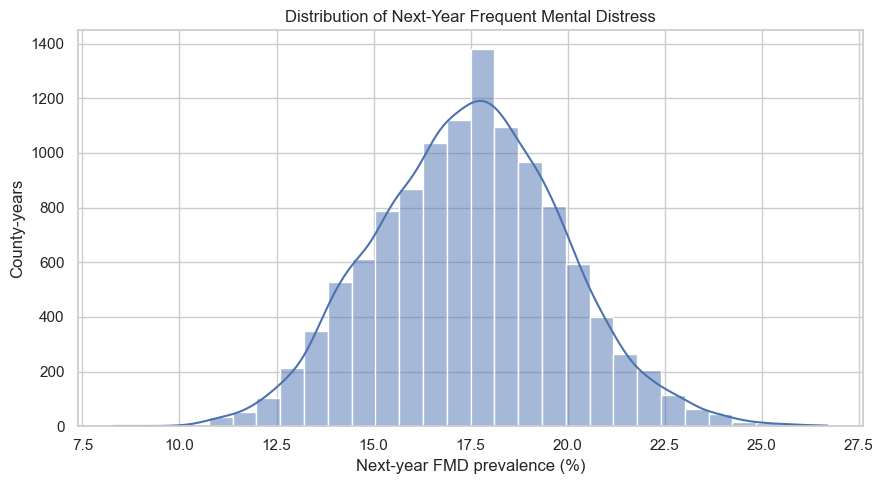

In [98]:
plt.figure(figsize=(9, 5))
sns.histplot(supervised_df["next_year_fmd"], bins=30, kde=True)
plt.title("Distribution of Next-Year Frequent Mental Distress")
plt.xlabel("Next-year FMD prevalence (%)")
plt.ylabel("County-years")
plt.tight_layout()
plt.show()

## 3. Feature Sets

The supervised models use current-year features only. The unsupervised models exclude FMD and FMD confidence intervals, so that the cluster evaluation can treat mental distress as a held-out outcome.

In [101]:
TARGET = "next_year_fmd"
CURRENT_FMD = "mental_health_prevalence"
ID_COLS = ["geoid", "county_name", "state_name", "year", "next_year", "geometry"]
FMD_RELATED = ["mental_health_prevalence", "lower_ci", "upper_ci", "next_year_fmd"]

# Convert comma-formatted population field if present.
for frame in (supervised_df, df):
    if "total_population" in frame.columns:
        frame["total_population_numeric"] = (
            frame["total_population"].astype(str).str.replace(",", "", regex=False).replace("nan", np.nan).astype(float)
        )

numeric_cols = supervised_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [
    c for c in numeric_cols
    if c not in FMD_RELATED + ["next_year"]
]

# `geoid` became string, so it is not in numeric_cols; keep IDs out if a future read infers otherwise.
feature_cols = [c for c in feature_cols if c not in ID_COLS]

air_quality_features = [c for c in feature_cols if any(token in c.lower() for token in ["aqi", "days", "co", "no2", "ozone", "pm2.5", "pm10", "unhealthy", "hazardous", "good", "moderate"])]
socioeconomic_features = [c for c in feature_cols if c not in air_quality_features]

print(f"Model features ({len(feature_cols)}):")
for col in feature_cols:
    print("-", col)

print("\nAir-quality feature count:", len(air_quality_features))
print("Socioeconomic/other feature count:", len(socioeconomic_features))

Model features (20):
- median_income
- poverty_count
- population
- unemployed_count
- Days with AQI
- Good Days
- Moderate Days
- Unhealthy for Sensitive Groups Days
- Unhealthy Days
- Very Unhealthy Days
- Hazardous Days
- Max AQI
- 90th Percentile AQI
- Median AQI
- Days CO
- Days NO2
- Days Ozone
- Days PM2.5
- Days PM10
- total_population_numeric

Air-quality feature count: 18
Socioeconomic/other feature count: 2


In [103]:
feature_overview = supervised_df[feature_cols + [CURRENT_FMD, TARGET]].describe().T
feature_overview["missing"] = supervised_df[feature_cols + [CURRENT_FMD, TARGET]].isna().sum()
display(feature_overview)

,count,mean,std,min,25%,50%,75%,max,missing
median_income,11673.0,-56782.767326,8.726739e+06,-666666666.0,47335.000000,55114.000000,64432.000000,170463.0,0
poverty_count,11673.0,12792.189411,4.548892e+04,0.0,1478.000000,3639.000000,8680.000000,1480446.0,0
population,11673.0,102768.949285,3.379453e+05,48.0,10700.000000,25435.000000,66452.000000,10081570.0,0
unemployed_count,11673.0,2784.453611,1.085520e+04,0.0,222.000000,576.000000,1633.000000,367715.0,0
Days with AQI,11673.0,319.371150,4.877619e+01,7.0,299.452715,328.816531,358.644394,366.0,0
Good Days,11673.0,238.967185,4.995027e+01,7.0,213.036033,238.724510,268.445585,365.0,0
Moderate Days,11673.0,77.963770,4.261206e+01,0.0,48.303486,73.897167,101.180614,302.0,0
Unhealthy for Sensitive Groups Days,11673.0,1.890888,5.123226e+00,0.0,0.086306,0.702477,2.000000,109.0,0
Unhealthy Days,11673.0,0.412136,2.218324e+00,0.0,0.000000,0.000000,0.130702,69.0,0
Very Unhealthy Days,11673.0,0.089001,1.123622e+00,0.0,0.000000,0.000000,0.000000,75.0,0


## 4. Supervised Learning

### Evaluation design

- **Final holdout:** feature year 2022 predicting FMD in 2023.
- **Training/CV:** earlier feature years, grouped by year where possible.
- **Metrics:** RMSE, MAE, and R².
- **Models:** Dummy baseline, ElasticNet, Random Forest, and Gradient Boosting.

This is stricter than a random split because random county-year splitting can let the model learn information from nearby years for the same counties.

In [106]:
holdout_feature_year = supervised_df["year"].max()
train_df = supervised_df[supervised_df["year"] < holdout_feature_year].copy()
test_df = supervised_df[supervised_df["year"] == holdout_feature_year].copy()

X_train = train_df[feature_cols]
y_train = train_df[TARGET]
X_test = test_df[feature_cols]
y_test = test_df[TARGET]

groups = train_df["year"]

print(f"Training rows: {len(train_df):,} from feature years {sorted(train_df['year'].unique())}")
print(f"Holdout rows: {len(test_df):,} from feature year {holdout_feature_year}, predicting {int(test_df['next_year'].mode()[0])}")

Training rows: 8,861 from feature years [2019, 2020, 2021]
Holdout rows: 2,812 from feature year 2022, predicting 2023


In [108]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def evaluate_model(name, estimator, X_train, y_train, X_test, y_test):
    estimator.fit(X_train, y_train)
    pred = estimator.predict(X_test)
    return {
        "model": name,
        "rmse": rmse(y_test, pred),
        "mae": mean_absolute_error(y_test, pred),
        "r2": r2_score(y_test, pred),
        "estimator": estimator,
        "predictions": pred,
    }

models = {
    "Dummy mean baseline": DummyRegressor(strategy="mean"),
    "ElasticNet": Pipeline([
        ("scale", StandardScaler()),
        ("model", ElasticNet(max_iter=50_000, random_state=RANDOM_STATE))
    ]),
    "Random Forest": RandomForestRegressor(
        n_estimators=400,
        min_samples_leaf=3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

results = []
for name, model in models.items():
    results.append(evaluate_model(name, model, X_train, y_train, X_test, y_test))

results_df = pd.DataFrame([{k: v for k, v in row.items() if k not in ["estimator", "predictions"]} for row in results])
results_df = results_df.sort_values("rmse")
display(results_df)

,model,rmse,mae,r2
2,Random Forest,2.345370,1.979051,-0.428624
3,Gradient Boosting,2.427615,2.065088,-0.530576
0,Dummy mean baseline,2.432019,1.954795,-0.536135
1,ElasticNet,2.432019,1.954795,-0.536135


In [109]:
cv_rows = []
cv = GroupKFold(n_splits=train_df["year"].nunique())
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
}

for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, groups=groups, scoring=scoring, n_jobs=-1)
    cv_rows.append({
        "model": name,
        "cv_rmse_mean": -scores["test_rmse"].mean(),
        "cv_rmse_sd": scores["test_rmse"].std(),
        "cv_mae_mean": -scores["test_mae"].mean(),
        "cv_r2_mean": scores["test_r2"].mean(),
    })

cv_df = pd.DataFrame(cv_rows).sort_values("cv_rmse_mean")
display(cv_df)

,model,cv_rmse_mean,cv_rmse_sd,cv_mae_mean,cv_r2_mean
2,Random Forest,2.402558,0.733804,2.063206,-0.405945
3,Gradient Boosting,2.445725,0.699987,2.096266,-0.436845
0,Dummy mean baseline,2.729924,0.455684,2.229633,-0.696172
1,ElasticNet,2.729924,0.455684,2.229633,-0.696172


### Optional Hyperparameter Tuning

This small grid keeps runtime reasonable. Expand the grids if you need a stronger final model for the report.

In [111]:
elastic_grid = GridSearchCV(
    Pipeline([
        ("scale", StandardScaler()),
        ("model", ElasticNet(max_iter=50_000, random_state=RANDOM_STATE))
    ]),
    param_grid={
        "model__alpha": [0.001, 0.01, 0.1, 1.0, 10.0],
        "model__l1_ratio": [0.1, 0.5, 0.9],
    },
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
)

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid={
        "n_estimators": [250, 500],
        "max_features": ["sqrt", 0.7],
        "min_samples_leaf": [1, 3, 8],
    },
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
)

gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_STATE),
    param_grid={
        "n_estimators": [100, 250],
        "learning_rate": [0.03, 0.07, 0.1],
        "max_depth": [2, 3],
    },
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
)

tuned_models = {
    "ElasticNet tuned": elastic_grid,
    "Random Forest tuned": rf_grid,
    "Gradient Boosting tuned": gb_grid,
}

tuned_results = []
for name, search in tuned_models.items():
    search.fit(X_train, y_train, groups=groups)
    pred = search.predict(X_test)
    tuned_results.append({
        "model": name,
        "best_params": search.best_params_,
        "cv_rmse": -search.best_score_,
        "holdout_rmse": rmse(y_test, pred),
        "holdout_mae": mean_absolute_error(y_test, pred),
        "holdout_r2": r2_score(y_test, pred),
        "estimator": search.best_estimator_,
        "predictions": pred,
    })

tuned_results_df = pd.DataFrame([{k: v for k, v in row.items() if k not in ["estimator", "predictions"]} for row in tuned_results])
display(tuned_results_df.sort_values("holdout_rmse"))

,model,best_params,cv_rmse,holdout_rmse,holdout_mae,holdout_r2
1,Random Forest tuned,"{'max_features': 'sqrt', 'min_samples_leaf': 1...",2.333879,2.170424,1.827102,-0.223445
0,ElasticNet tuned,"{'model__alpha': 0.1, 'model__l1_ratio': 0.9}",2.682246,2.360249,1.882191,-0.446808
2,Gradient Boosting tuned,"{'learning_rate': 0.03, 'max_depth': 3, 'n_est...",2.411305,2.415031,2.054018,-0.514750


In [112]:
all_model_objects = {row["model"]: row for row in results}
all_model_objects.update({row["model"]: row for row in tuned_results})

best_name = min(all_model_objects, key=lambda name: all_model_objects[name].get("holdout_rmse", all_model_objects[name].get("rmse", np.inf)))
best = all_model_objects[best_name]
best_estimator = best["estimator"]
best_pred = best["predictions"]

print("Best holdout model:", best_name)
print("Holdout RMSE:", rmse(y_test, best_pred))
print("Holdout R²:", r2_score(y_test, best_pred))

Best holdout model: Random Forest tuned
Holdout RMSE: 2.170423778015148
Holdout R²: -0.22344492841985164


### Supervised Visualizations

These plots support the report requirements: predicted-vs-actual, residual diagnostics, and feature influence.

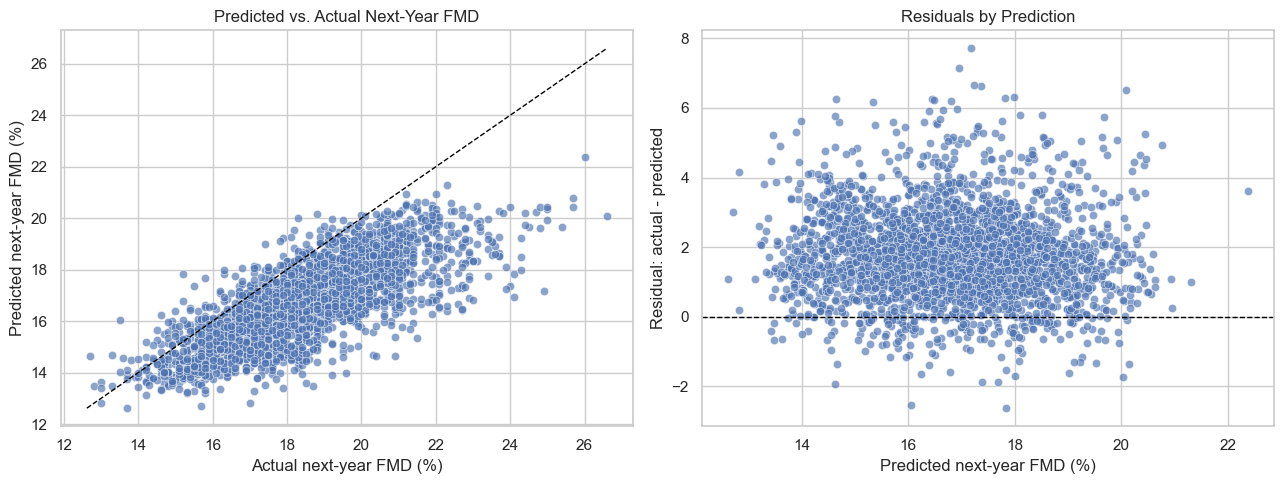

In [114]:
pred_df = test_df[["geoid", "county_name", "state_name", "year", "next_year", TARGET]].copy()
pred_df["prediction"] = best_pred
pred_df["residual"] = pred_df[TARGET] - pred_df["prediction"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=pred_df, x=TARGET, y="prediction", alpha=0.65, ax=axes[0])
lims = [min(pred_df[TARGET].min(), pred_df["prediction"].min()), max(pred_df[TARGET].max(), pred_df["prediction"].max())]
axes[0].plot(lims, lims, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Predicted vs. Actual Next-Year FMD")
axes[0].set_xlabel("Actual next-year FMD (%)")
axes[0].set_ylabel("Predicted next-year FMD (%)")

sns.scatterplot(data=pred_df, x="prediction", y="residual", alpha=0.65, ax=axes[1])
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Residuals by Prediction")
axes[1].set_xlabel("Predicted next-year FMD (%)")
axes[1].set_ylabel("Residual: actual - predicted")

plt.tight_layout()
plt.show()

,feature,importance
0,median_income,0.193433
1,poverty_count,0.073673
18,Days PM10,0.064944
19,total_population_numeric,0.060205
2,population,0.059769
13,Median AQI,0.059242
3,unemployed_count,0.057664
11,Max AQI,0.050134
6,Moderate Days,0.049567
5,Good Days,0.047139


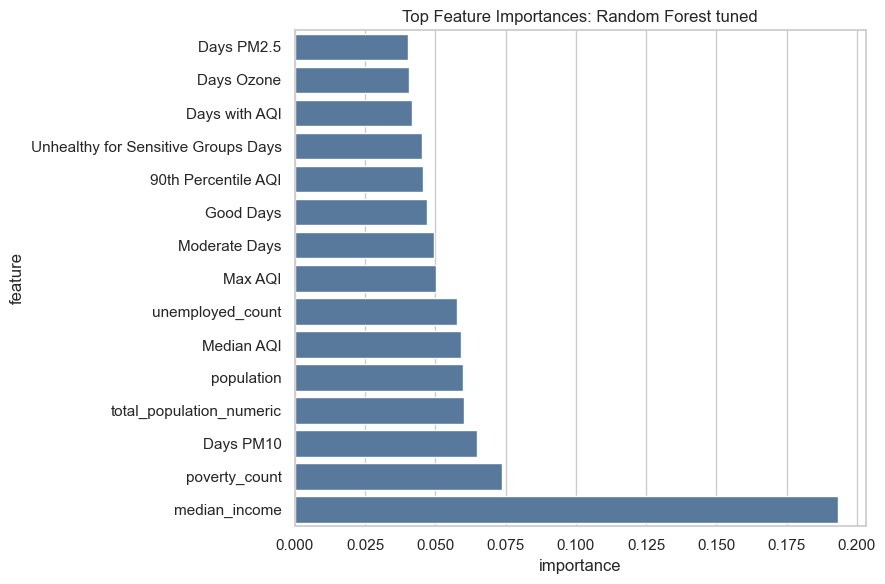

In [115]:
def get_feature_importance(estimator, feature_names):
    final = estimator
    if isinstance(estimator, Pipeline):
        final = estimator.named_steps.get("model", estimator.steps[-1][1])

    if hasattr(final, "feature_importances_"):
        values = final.feature_importances_
        label = "importance"
    elif hasattr(final, "coef_"):
        values = final.coef_
        label = "coefficient"
    else:
        return None, None

    return pd.DataFrame({"feature": feature_names, label: values}).sort_values(label, key=lambda s: s.abs(), ascending=False), label

importance_df, importance_label = get_feature_importance(best_estimator, feature_cols)
if importance_df is not None:
    display(importance_df.head(15))
    plt.figure(figsize=(9, 6))
    plot_df = importance_df.head(15).sort_values(importance_label)
    sns.barplot(data=plot_df, x=importance_label, y="feature", color="#4C78A8")
    plt.title(f"Top Feature {importance_label.title()}s: {best_name}")
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_name} does not expose simple feature importances or coefficients.")

In [116]:
state_errors = (
    pred_df.groupby("state_name")
    .agg(
        n=("geoid", "count"),
        mean_actual=(TARGET, "mean"),
        mean_prediction=("prediction", "mean"),
        mean_residual=("residual", "mean"),
        rmse=("residual", lambda s: np.sqrt(np.mean(np.square(s)))),
    )
    .sort_values("rmse", ascending=False)
)
display(state_errors.head(15))

,n,mean_actual,mean_prediction,mean_residual,rmse
state_name,,,,,
West Virginia,55,23.434545,18.324440,5.110105,5.194651
Maine,16,20.043750,16.311588,3.732162,3.837118
Tennessee,95,21.692632,18.199200,3.493432,3.577346
Montana,56,19.248214,16.160618,3.087596,3.447953
Nevada,17,19.635294,16.751682,2.883612,3.075054
Iowa,99,17.750505,15.035846,2.714659,2.874260
South Dakota,66,17.210606,14.871715,2.338891,2.784841
Massachusetts,14,17.442857,15.076343,2.366514,2.688764
Ohio,88,19.473864,17.139811,2.334052,2.601652


## 5. Unsupervised Learning

### Design

The clustering stage uses only environmental and socioeconomic features, excluding FMD and confidence intervals. FMD is brought back afterward as a hold-out outcome for interpretation and ANOVA.

UMAP is attempted first because it matches the project plan. If `umap-learn` is unavailable, the notebook falls back to PCA so the workflow remains runnable.

In [118]:
cluster_df = df.copy()
cluster_df = cluster_df[cluster_df["year"] == cluster_df["year"].max()].copy()

# Use latest year for cross-sectional county archetypes. Drop columns that should not define clusters.
cluster_numeric_cols = cluster_df.select_dtypes(include=[np.number]).columns.tolist()
exclude_from_clustering = set(["next_year", "next_year_fmd", "mental_health_prevalence", "lower_ci", "upper_ci"])
cluster_features = [c for c in cluster_numeric_cols if c not in exclude_from_clustering]

# Keep model features if available, plus any numeric socioeconomic additions.
cluster_features = [c for c in cluster_features if c in feature_cols or c == "total_population_numeric"]

print(f"Clustering {len(cluster_df):,} counties from year {cluster_df['year'].iloc[0]}")
print(f"Cluster features ({len(cluster_features)}):")
for col in cluster_features:
    print("-", col)

X_cluster = cluster_df[cluster_features].replace([np.inf, -np.inf], np.nan)
X_cluster = X_cluster.fillna(X_cluster.median(numeric_only=True))
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

Clustering 2,812 counties from year 2023
Cluster features (20):
- median_income
- poverty_count
- population
- unemployed_count
- Days with AQI
- Good Days
- Moderate Days
- Unhealthy for Sensitive Groups Days
- Unhealthy Days
- Very Unhealthy Days
- Hazardous Days
- Max AQI
- 90th Percentile AQI
- Median AQI
- Days CO
- Days NO2
- Days Ozone
- Days PM2.5
- Days PM10
- total_population_numeric


In [124]:
# if HAS_UMAP:
#     reducer = umap.UMAP(
#         n_neighbors=30,
#         min_dist=0.08,
#         n_components=2,
#         metric="euclidean",
#         random_state=RANDOM_STATE,
#     )
#     embedding = reducer.fit_transform(X_cluster_scaled)
#     embedding_method = "UMAP"
# else:
#     reducer = PCA(n_components=2, random_state=RANDOM_STATE)
#     embedding = reducer.fit_transform(X_cluster_scaled)
#     embedding_method = "PCA fallback"
#     print("umap-learn is not installed. Using PCA fallback; install umap-learn for the planned UMAP embedding.")

# cluster_df["embed_1"] = embedding[:, 0]
# cluster_df["embed_2"] = embedding[:, 1]
# print("Embedding method:", embedding_method)

In [126]:
if HAS_UMAP:
    reducer = umap.UMAP(
        n_neighbors=30,
        min_dist=0.08,
        n_components=2,
        metric="euclidean",
        random_state=RANDOM_STATE,
    )
    embedding = reducer.fit_transform(X_cluster_scaled)
    embedding_method = "UMAP"
else:
    reducer = PCA(n_components=2, random_state=RANDOM_STATE)
    embedding = reducer.fit_transform(X_cluster_scaled)
    embedding_method = "PCA fallback"
    print("umap-learn is not installed. Using PCA fallback; install umap-learn for the planned UMAP embedding.")

cluster_df["embed_1"] = embedding[:, 0]
cluster_df["embed_2"] = embedding[:, 1]

# Alias used by downstream DBSCAN cells
embedding_for_cluster = embedding

print("Embedding method:", embedding_method)
print("Embedding shape:", embedding_for_cluster.shape)

umap-learn is not installed. Using PCA fallback; install umap-learn for the planned UMAP embedding.
Embedding method: PCA fallback
Embedding shape: (2812, 2)


In [128]:
# Search DBSCAN settings on the 2D embedding. Noise points are labeled -1.
search_rows = []
for eps in np.round(np.linspace(0.15, 1.50, 10), 2):
    for min_samples in [5, 10, 20, 35, 50]:
        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(embedding_for_cluster)
        non_noise = labels != -1
        n_clusters = len(set(labels[non_noise]))
        noise_pct = 1 - non_noise.mean()
        sil_embed = np.nan
        sil_scaled = np.nan
        if n_clusters >= 2 and non_noise.sum() > n_clusters:
            sil_embed = silhouette_score(embedding_for_cluster[non_noise], labels[non_noise])
            sil_scaled = silhouette_score(X_cluster_scaled[non_noise], labels[non_noise])
        search_rows.append({
            "eps": eps,
            "min_samples": min_samples,
            "clusters": n_clusters,
            "noise_pct": noise_pct,
            "silhouette_embedding": sil_embed,
            "silhouette_scaled_features": sil_scaled,
        })

search_df = pd.DataFrame(search_rows)
valid_search = search_df[search_df["clusters"].between(2, 12)].copy()
if valid_search.empty:
    best_params = search_df.sort_values(["clusters", "noise_pct"], ascending=[False, True]).iloc[0]
else:
    best_params = valid_search.sort_values(["silhouette_embedding", "silhouette_scaled_features"], ascending=False).iloc[0]

display(search_df.sort_values(["silhouette_embedding", "silhouette_scaled_features"], ascending=False).head(15))
print("Selected DBSCAN parameters:")
print(best_params)

,eps,min_samples,clusters,noise_pct,silhouette_embedding,silhouette_scaled_features
35,1.20,5,2,0.013869,0.695256,0.493833
40,1.35,5,3,0.011380,0.693513,0.491969
30,1.05,5,3,0.013869,0.655153,0.466692
16,0.60,10,2,0.051920,0.616421,0.375769
21,0.75,10,2,0.034139,0.596886,0.373245
32,1.05,20,2,0.031294,0.588048,0.352116
20,0.75,5,3,0.021337,0.585577,0.484766
3,0.15,35,2,0.498578,0.443672,0.201110
15,0.60,5,5,0.025960,0.442773,0.207805
10,0.45,5,4,0.041607,0.431577,0.319610


Selected DBSCAN parameters:
eps                           1.200000
min_samples                   5.000000
clusters                      2.000000
noise_pct                     0.013869
silhouette_embedding          0.695256
silhouette_scaled_features    0.493833
Name: 35, dtype: float64


In [130]:
dbscan = DBSCAN(eps=float(best_params["eps"]), min_samples=int(best_params["min_samples"]))
cluster_df["cluster"] = dbscan.fit_predict(embedding_for_cluster)

cluster_counts = cluster_df["cluster"].value_counts().sort_index().rename_axis("cluster").reset_index(name="count")
cluster_counts["share"] = cluster_counts["count"] / len(cluster_df)
display(cluster_counts)

non_noise = cluster_df["cluster"] != -1
n_clusters = cluster_df.loc[non_noise, "cluster"].nunique()
if n_clusters >= 2:
    print("Silhouette on embedding:", silhouette_score(embedding_for_cluster[non_noise.to_numpy()], cluster_df.loc[non_noise, "cluster"]))
    print("Silhouette on scaled original features:", silhouette_score(X_cluster_scaled[non_noise.to_numpy()], cluster_df.loc[non_noise, "cluster"]))
else:
    print("DBSCAN found fewer than two non-noise clusters; adjust eps/min_samples above.")

,cluster,count,share
0,-1,39,0.013869
1,0,2768,0.984353
2,1,5,0.001778


Silhouette on embedding: 0.6952559763713482
Silhouette on scaled original features: 0.49383332480901415


### Cluster Visualization and Hold-Out FMD Test

The scatterplot shows how the clustering behaves in the low-dimensional space. The summaries and ANOVA test ask whether the clusters differ on mental distress despite FMD not being used to form them.

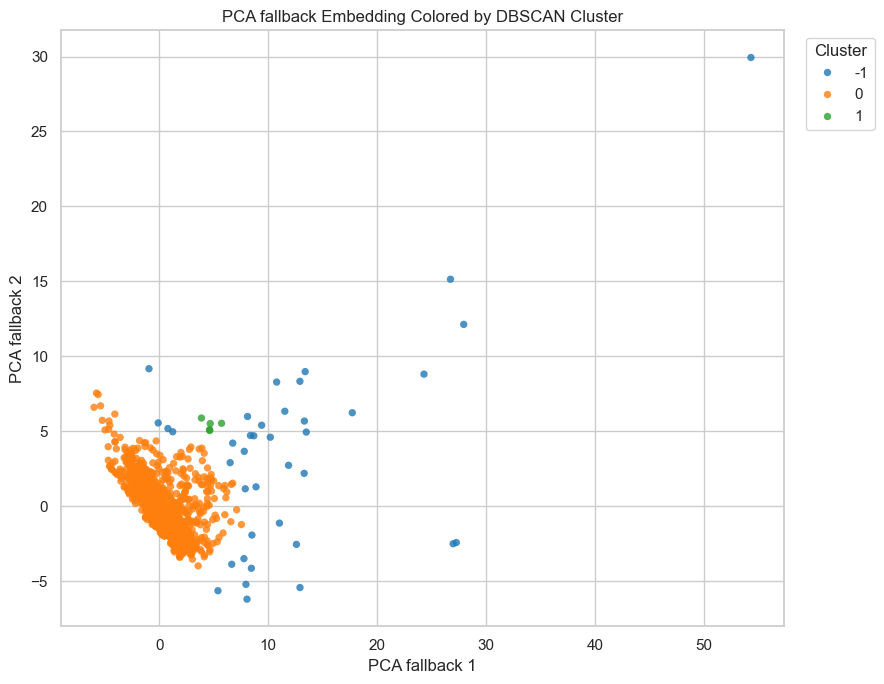

In [133]:
plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=cluster_df,
    x="embed_1",
    y="embed_2",
    hue="cluster",
    palette="tab10",
    s=28,
    alpha=0.8,
    linewidth=0,
)
plt.title(f"{embedding_method} Embedding Colored by DBSCAN Cluster")
plt.xlabel(f"{embedding_method} 1")
plt.ylabel(f"{embedding_method} 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [135]:
cluster_profile = (
    cluster_df.groupby("cluster")
    .agg(
        counties=("geoid", "count"),
        avg_fmd=("mental_health_prevalence", "mean"),
        median_fmd=("mental_health_prevalence", "median"),
        avg_median_aqi=("Median AQI", "mean"),
        avg_max_aqi=("Max AQI", "mean"),
        avg_income=("median_income", "mean"),
        avg_poverty_count=("poverty_count", "mean"),
        avg_unemployed_count=("unemployed_count", "mean"),
        avg_population=("population", "mean"),
    )
    .sort_values("avg_fmd", ascending=False)
)
display(cluster_profile)

,counties,avg_fmd,median_fmd,avg_median_aqi,avg_max_aqi,avg_income,avg_poverty_count,avg_unemployed_count,avg_population
cluster,,,,,,,,,
0,2768,18.600795,18.6,41.370679,144.454946,-415683.752529,9197.647760,1902.702673,7.862854e+04
-1,39,17.025641,16.9,55.102564,254.358974,82868.769231,262104.897436,63154.692308,1.964555e+06
1,5,15.460000,15.4,41.800000,133.400000,114581.600000,137830.800000,41511.400000,1.599959e+06


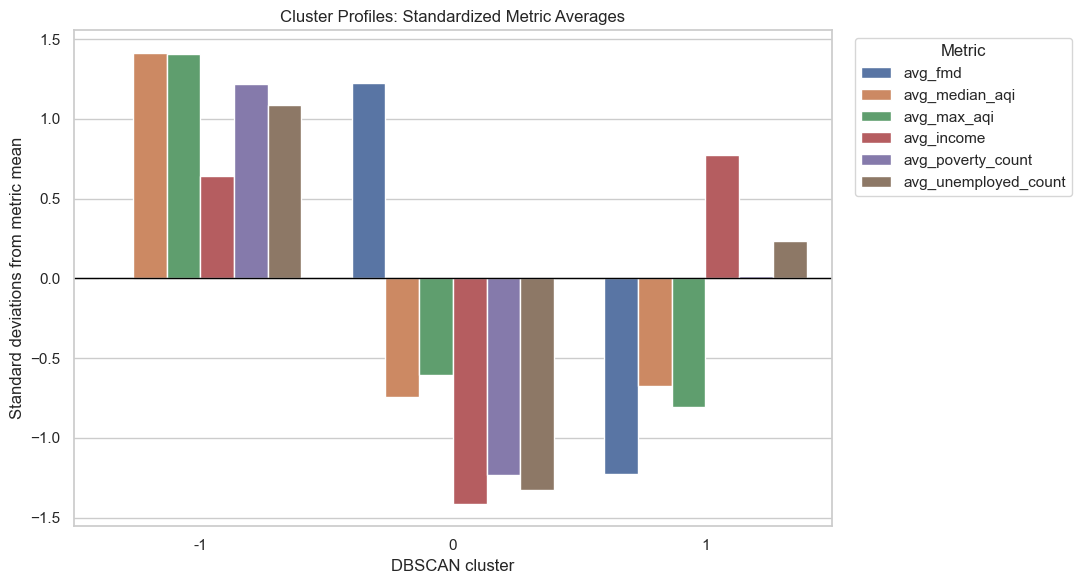

In [137]:
plot_profile = cluster_profile.reset_index().melt(
    id_vars=["cluster"],
    value_vars=["avg_fmd", "avg_median_aqi", "avg_max_aqi", "avg_income", "avg_poverty_count", "avg_unemployed_count"],
    var_name="metric",
    value_name="value",
)

# Standardize metrics for a readable grouped comparison.
plot_profile["z_value"] = plot_profile.groupby("metric")["value"].transform(lambda s: (s - s.mean()) / s.std(ddof=0) if s.std(ddof=0) else 0)

plt.figure(figsize=(11, 6))
sns.barplot(data=plot_profile, x="cluster", y="z_value", hue="metric")
plt.axhline(0, color="black", linewidth=1)
plt.title("Cluster Profiles: Standardized Metric Averages")
plt.xlabel("DBSCAN cluster")
plt.ylabel("Standard deviations from metric mean")
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [139]:
if HAS_SCIPY and cluster_df.loc[cluster_df["cluster"] != -1, "cluster"].nunique() >= 2:
    groups_for_anova = [
        group["mental_health_prevalence"].dropna().values
        for _, group in cluster_df[cluster_df["cluster"] != -1].groupby("cluster")
    ]
    f_stat, p_value = f_oneway(*groups_for_anova)
    print(f"ANOVA on held-out FMD across non-noise clusters: F={f_stat:.3f}, p={p_value:.4g}")
else:
    print("ANOVA skipped: scipy is unavailable or DBSCAN found fewer than two non-noise clusters.")

ANOVA on held-out FMD across non-noise clusters: F=12.902, p=0.0003339


In [141]:
# Identify the features that make each cluster stand out relative to the full latest-year county sample.
feature_means = cluster_df.groupby("cluster")[cluster_features].mean()
overall_means = cluster_df[cluster_features].mean()
overall_stds = cluster_df[cluster_features].std(ddof=0).replace(0, np.nan)
z_profiles = (feature_means - overall_means) / overall_stds

top_drivers = []
for cluster_id, row in z_profiles.iterrows():
    strongest = row.abs().sort_values(ascending=False).head(6).index
    for feature in strongest:
        top_drivers.append({
            "cluster": cluster_id,
            "feature": feature,
            "z_difference": row[feature],
            "direction": "above average" if row[feature] > 0 else "below average",
        })

top_drivers_df = pd.DataFrame(top_drivers)
display(top_drivers_df)

,cluster,feature,z_difference,direction
0,-1,poverty_count,5.545376,above average
1,-1,total_population_numeric,5.345018,above average
2,-1,population,5.344425,above average
3,-1,unemployed_count,5.329753,above average
4,-1,Unhealthy for Sensitive Groups Days,3.428271,above average
5,-1,Unhealthy Days,3.015254,above average
6,0,poverty_count,-0.083153,below average
7,0,total_population_numeric,-0.083120,below average
8,0,population,-0.083059,below average
9,0,unemployed_count,-0.081268,below average


## 6. Optional Geographic Views

We wanted to use choropleth-inspired spatial visualization. The imputed CSV contains point WKT geometries, so this section maps county centroids/points rather than full county polygons. (If someone wants to come in and later add a county boundary shapefile, they would need to replace the point geometry with polygon geometries for a true choropleth).

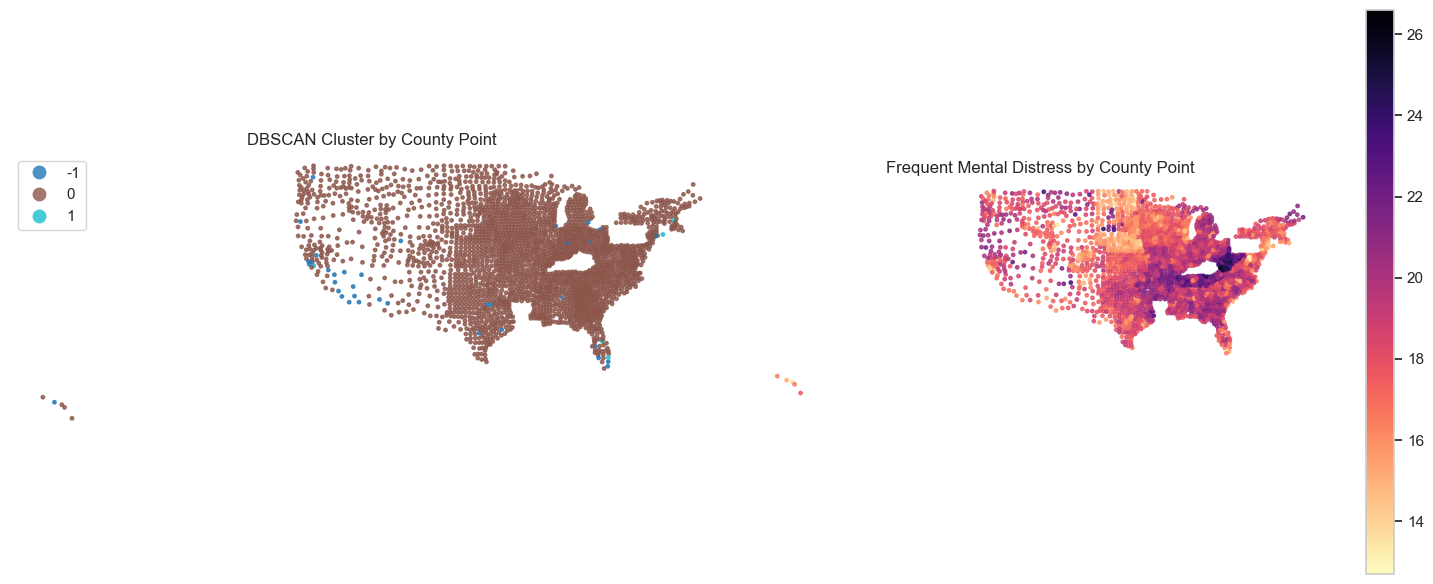

In [144]:
if HAS_GEO and "geometry" in cluster_df.columns:
    geo_df = cluster_df.copy()
    geo_df["geometry"] = geo_df["geometry"].apply(wkt.loads)
    geo_df = gpd.GeoDataFrame(geo_df, geometry="geometry", crs="EPSG:4326")

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    geo_df.plot(column="cluster", categorical=True, legend=True, markersize=6, alpha=0.8, ax=axes[0])
    axes[0].set_title("DBSCAN Cluster by County Point")
    axes[0].set_axis_off()

    geo_df.plot(column="mental_health_prevalence", cmap="magma_r", legend=True, markersize=6, alpha=0.8, ax=axes[1])
    axes[1].set_title("Frequent Mental Distress by County Point")
    axes[1].set_axis_off()

    plt.tight_layout()
    plt.show()
else:
    print("Geographic plot skipped: geopandas/shapely is unavailable or geometry column is missing.")

## 7. Export Model Outputs for Reporting

These CSVs make it easier to create report tables and visuals without rerunning every cell.

In [147]:
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

supervised_predictions_path = OUTPUT_DIR / "supervised_holdout_predictions.csv"
model_metrics_path = OUTPUT_DIR / "supervised_model_metrics.csv"
cluster_assignments_path = OUTPUT_DIR / "unsupervised_cluster_assignments.csv"
cluster_profile_path = OUTPUT_DIR / "unsupervised_cluster_profile.csv"

pred_df.to_csv(supervised_predictions_path, index=False)
results_export = pd.concat([
    results_df.assign(section="base_models"),
    tuned_results_df.drop(columns=["best_params"], errors="ignore").rename(columns={"holdout_rmse": "rmse", "holdout_mae": "mae", "holdout_r2": "r2"}).assign(section="tuned_models"),
], ignore_index=True, sort=False)
results_export.to_csv(model_metrics_path, index=False)
cluster_df[["geoid", "county_name", "state_name", "year", "mental_health_prevalence", "cluster", "embed_1", "embed_2"]].to_csv(cluster_assignments_path, index=False)
cluster_profile.to_csv(cluster_profile_path)

print("Saved:")
for path in [supervised_predictions_path, model_metrics_path, cluster_assignments_path, cluster_profile_path]:
    print(path)

Saved:
/Users/sophiaboettcher/Milestone-II-Project/outputs/supervised_holdout_predictions.csv
/Users/sophiaboettcher/Milestone-II-Project/outputs/supervised_model_metrics.csv
/Users/sophiaboettcher/Milestone-II-Project/outputs/unsupervised_cluster_assignments.csv
/Users/sophiaboettcher/Milestone-II-Project/outputs/unsupervised_cluster_profile.csv
